In [ ]:
'''
import scipy.io.arff as arff
import pandas as pd

# Path to your ARFF file
file_path = '/content/drive/MyDrive/Autism-Adult-Data (3).arff'

try:
    # Load ARFF file
    data, meta = arff.loadarff(file_path)

    # Convert to DataFrame

    print("ARFF file loaded successfully!")


    # Convert byte strings to normal strings (ARFF often stores nominal values as bytes)
    df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)

    # Save to CSV
    csv_path = '/content/drive/MyDrive/Autism-Adult-Data.csv'
    df.to_csv(csv_path, index=False)

    print(f"File successfully converted to CSV and saved at:\n{csv_path}")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")
'''

'\nimport scipy.io.arff as arff\nimport pandas as pd\n\n# Path to your ARFF file\nfile_path = \'/content/drive/MyDrive/Autism-Adult-Data (3).arff\'\n\ntry:\n    # Load ARFF file\n    data, meta = arff.loadarff(file_path)\n\n    # Convert to DataFrame\n\n    print("ARFF file loaded successfully!")\n\n\n    # Convert byte strings to normal strings (ARFF often stores nominal values as bytes)\n    df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)\n\n    # Save to CSV\n    csv_path = \'/content/drive/MyDrive/Autism-Adult-Data.csv\'\n    df.to_csv(csv_path, index=False)\n\n    print(f"File successfully converted to CSV and saved at:\n{csv_path}")\n\nexcept FileNotFoundError:\n    print(f"Error: The file \'{file_path}\' was not found.")\nexcept Exception as e:\n    print(f"An error occurred: {e}")\n'

In [ ]:
import pandas as pd

csv_path = '/content/train (2).csv'

# Load CSV
df = pd.read_csv(csv_path)

# Print first 5 rows
print(df.head())


   ID  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0   1         1         0         1         0         1         0         1   
1   2         0         0         0         0         0         0         0   
2   3         1         1         1         1         1         1         1   
3   4         0         0         0         0         0         0         0   
4   5         0         0         0         0         0         0         0   

   A8_Score  A9_Score  ...  gender       ethnicity jaundice austim  \
0         0         1  ...       f               ?       no     no   
1         0         0  ...       m               ?       no     no   
2         1         1  ...       m  White-European       no    yes   
3         0         0  ...       f               ?       no     no   
4         0         0  ...       m               ?       no     no   

   contry_of_res used_app_before     result     age_desc  relation Class/ASD  
0        Austria         

In [ ]:
df.shape

(800, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,800.0,400.500000,231.084400,1.000000,200.750000,400.500000,600.250000,800.000000
A1_Score,800.0,0.560000,0.496697,0.000000,0.000000,1.000000,1.000000,1.000000
A2_Score,800.0,0.530000,0.499411,0.000000,0.000000,1.000000,1.000000,1.000000
A3_Score,800.0,0.450000,0.497805,0.000000,0.000000,0.000000,1.000000,1.000000
A4_Score,800.0,0.415000,0.493030,0.000000,0.000000,0.000000,1.000000,1.000000
A5_Score,800.0,0.395000,0.489157,0.000000,0.000000,0.000000,1.000000,1.000000
A6_Score,800.0,0.303750,0.460164,0.000000,0.000000,0.000000,1.000000,1.000000
A7_Score,800.0,0.397500,0.489687,0.000000,0.000000,0.000000,1.000000,1.000000
A8_Score,800.0,0.508750,0.500236,0.000000,0.000000,1.000000,1.000000,1.000000
A9_Score,800.0,0.495000,0.500288,0.000000,0.000000,0.000000,1.000000,1.000000


# Data Cleaning

In [ ]:
df.drop(['used_app_before','age_desc', 'relation','ID','ethnicity'], axis=1, inplace=True)

In [ ]:
#The same is the case with this column so let's clean this data and along with this let's convert 'yes' and 'no' to 0 and 1.
df = df.replace({'yes':1, 'no':0, '?':'Others', 'others':'Others'})


#Exploratory Data Analysis

In [ ]:
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,jaundice,austim,contry_of_res,result,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.172746,f,0,0,Austria,6.351166,0
1,0,0,0,0,0,0,0,0,0,0,47.750517,m,0,0,India,2.255185,0
2,1,1,1,1,1,1,1,1,1,1,7.380373,m,0,1,United States,14.851484,1
3,0,0,0,0,0,0,0,0,0,0,23.561927,f,0,0,United States,2.276617,0
4,0,0,0,0,0,0,0,0,0,0,43.205790,m,0,0,South Africa,-4.777286,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0,1,0,0,0,0,0,0,1,1,16.597187,m,0,0,New Zealand,12.999501,0
796,0,1,1,0,0,1,0,1,1,1,20.703001,m,0,0,Cyprus,13.561518,0
797,0,0,0,0,0,0,0,0,0,0,5.711481,m,1,0,New Zealand,2.653177,0
798,0,0,0,0,0,0,0,0,0,0,16.414305,f,0,0,Canada,9.069342,0


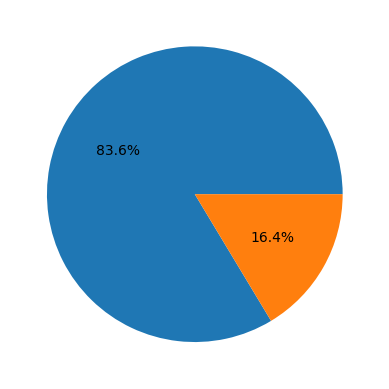

In [ ]:
plt.pie(df['austim'].value_counts().values, autopct='%1.1f%%')
plt.show()

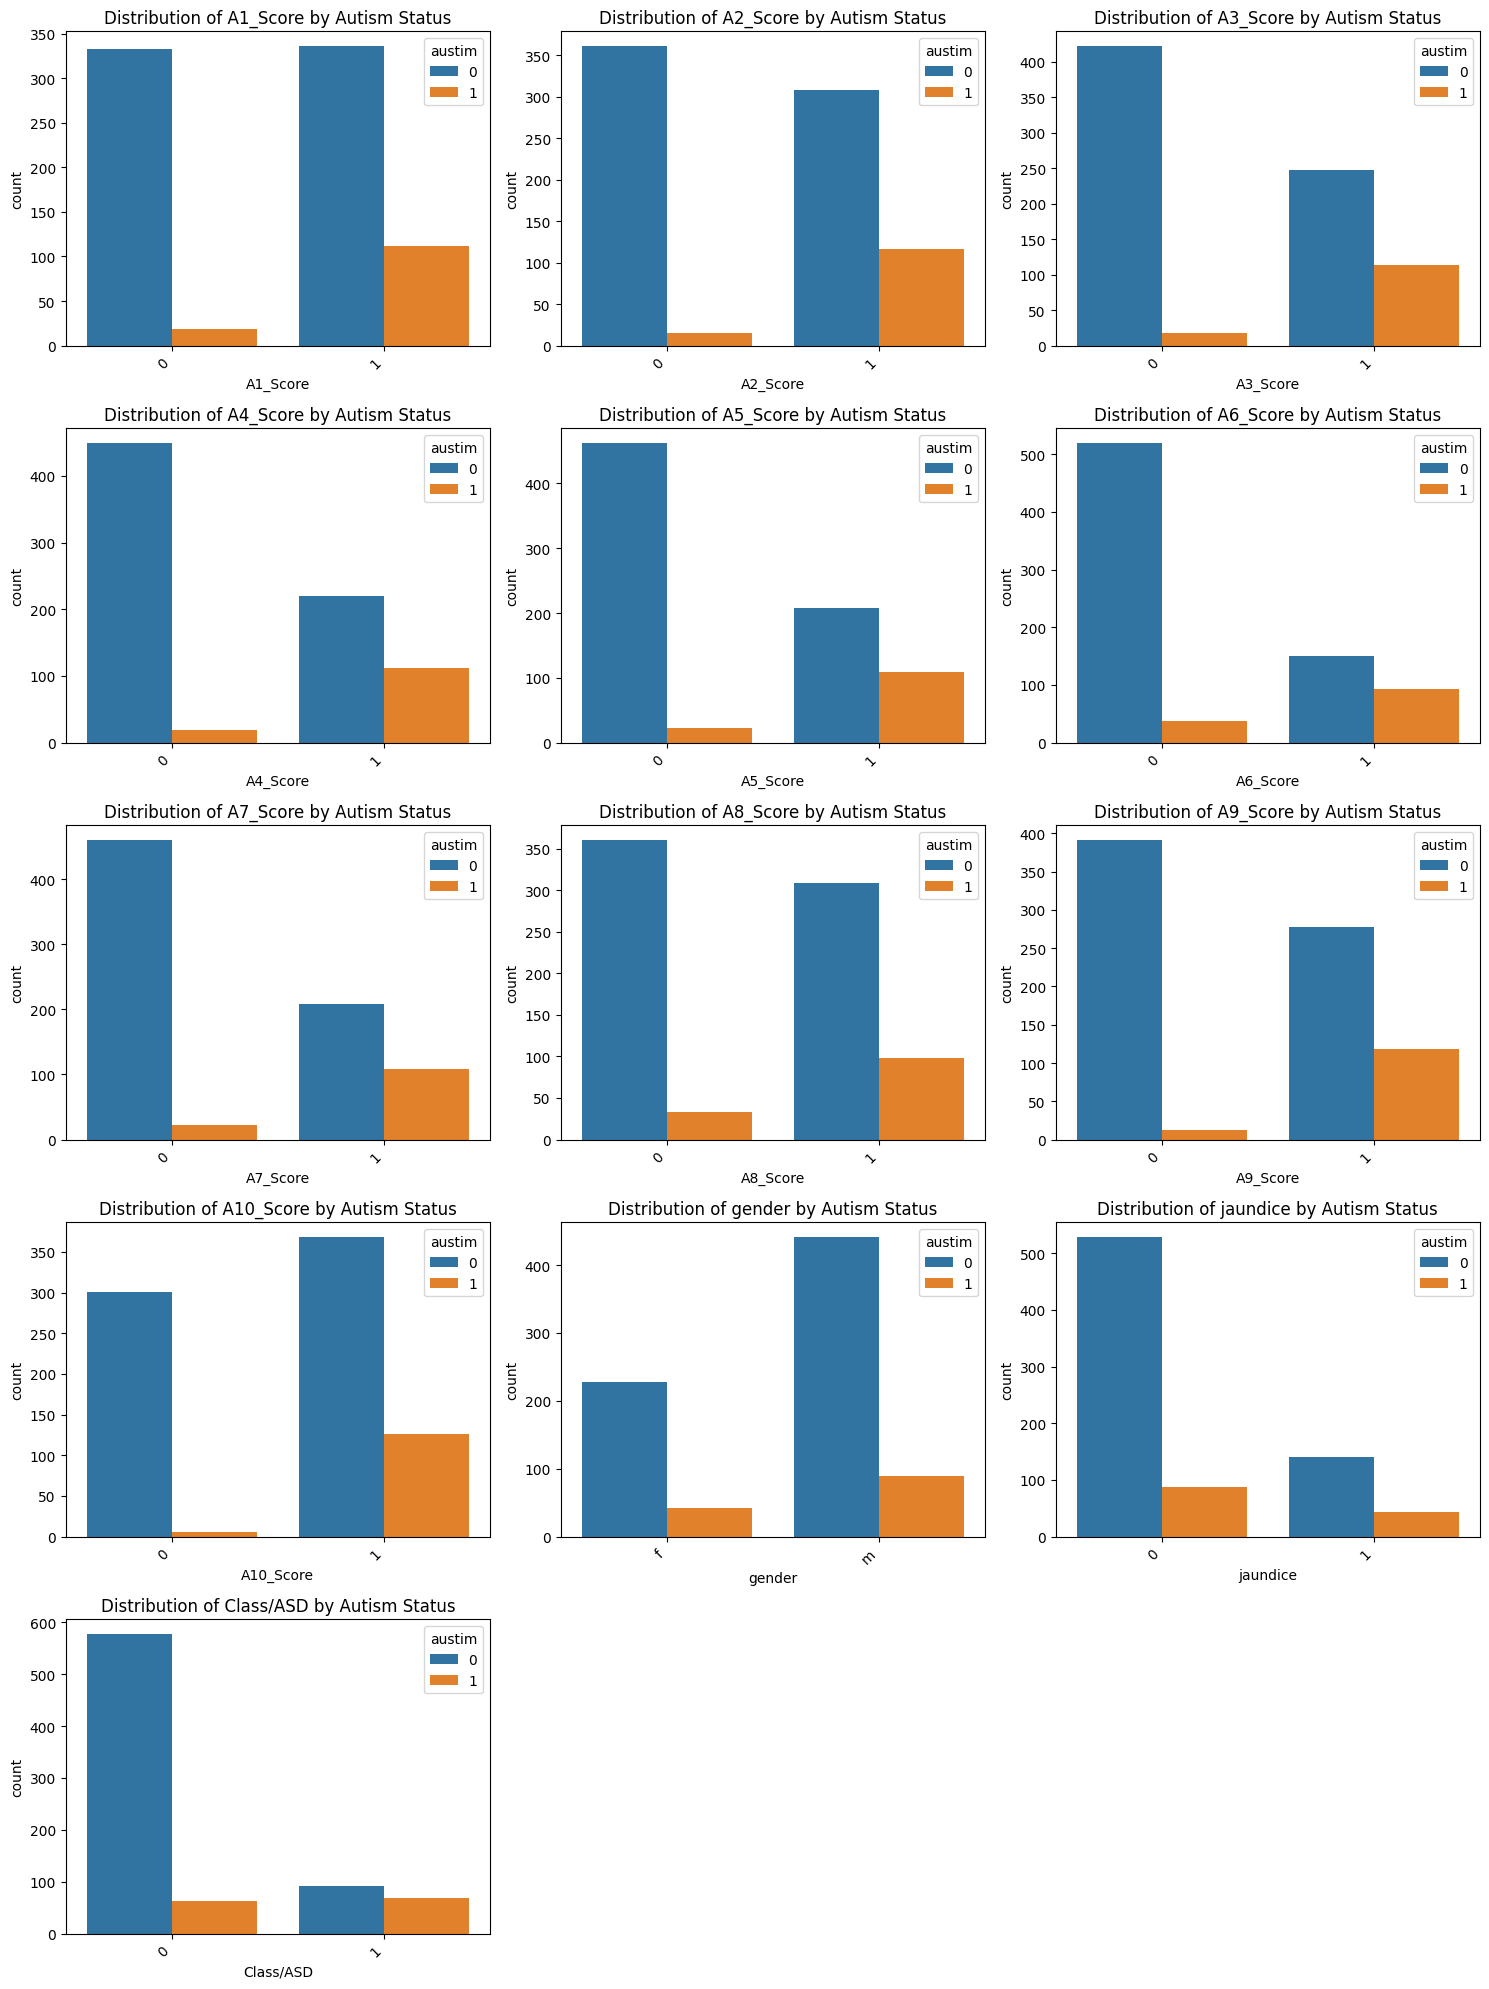

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all columns except 'austim' and the ones to be removed
columns_to_remove = ['austim', 'age', 'contry_of_res', 'result']
attributes = [col for col in df.columns if col not in columns_to_remove]

# Determine the number of rows and columns for the subplots
n_attributes = len(attributes)
n_cols = 3  # You can adjust this number
n_rows = (n_attributes + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(attributes):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=col, hue='austim', data=df)
    plt.title(f'Distribution of {col} by Autism Status')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.tight_layout()
plt.show()

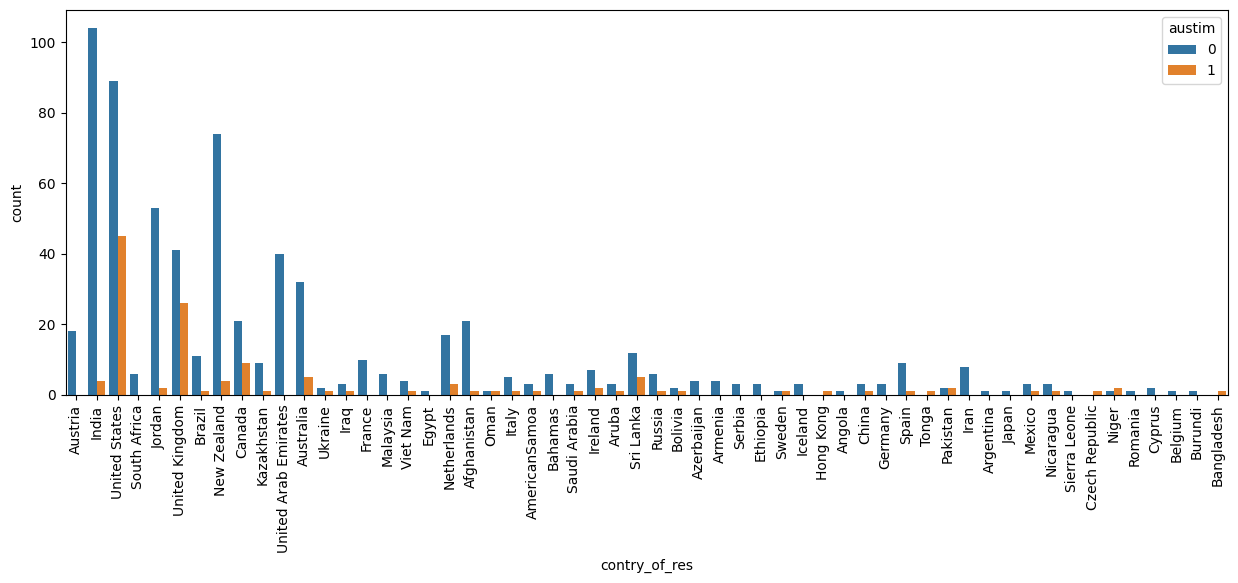

In [ ]:
plt.figure(figsize=(15,5))
sb.countplot(data=df, x='contry_of_res', hue='austim')
plt.xticks(rotation=90)
plt.show()

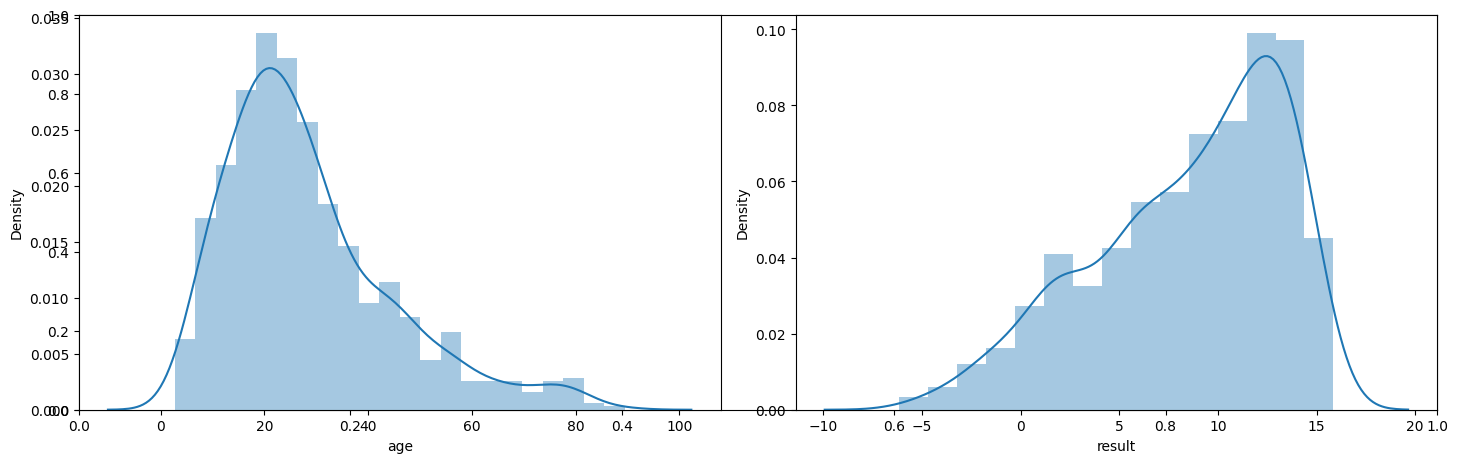

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

floats = ['age', 'result']

plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()

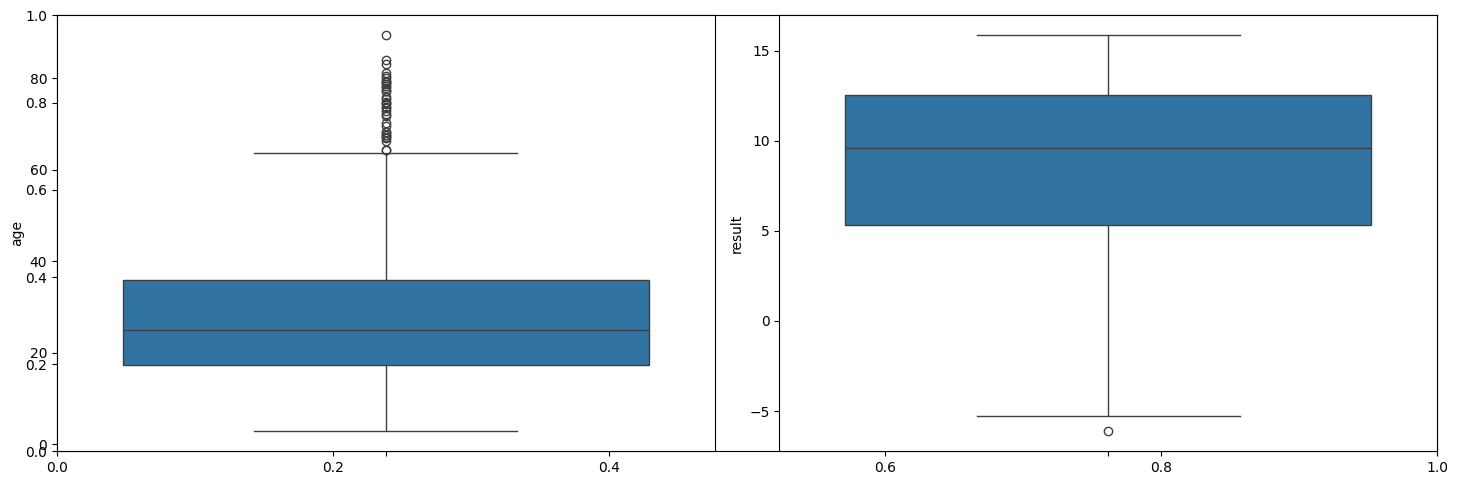

In [ ]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.boxplot(df[col])
plt.tight_layout()
plt.show()

In [ ]:
df = df[df['result']>-5]
df = df[df['age']<120]

df.shape

(798, 17)

Feature Engineering

In [ ]:
# This functions make groups by taking
# the age as a parameter
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        return 'Senior'

df['ageGroup'] = df['age'].apply(convertAge)

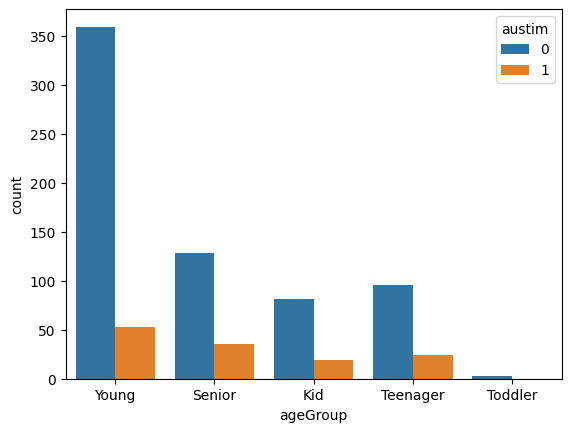

In [ ]:
sb.countplot(x=df['ageGroup'], hue=df['austim'])
plt.show()

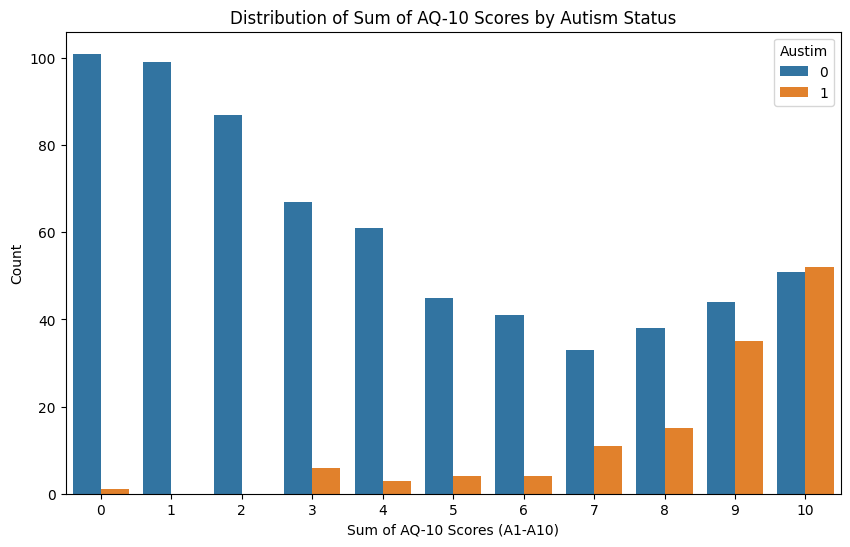

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb

# Ensure 'sum_score' is calculated if not already present
if 'sum_score' not in df.columns:
    df['sum_score'] = df[[f"A{i}_Score" for i in range(1,11)]].sum(axis=1)


plt.figure(figsize=(10, 6))
sb.countplot(x='sum_score', hue='austim', data=df)
plt.title('Distribution of Sum of AQ-10 Scores by Autism Status')
plt.xlabel('Sum of AQ-10 Scores (A1-A10)')
plt.ylabel('Count')
plt.legend(title='Austim')
plt.show()

In [ ]:
df['sum_score'] = df['sum_score']/10

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import pandas as pd

# Initialize MinMaxScaler
scaler = MinMaxScaler()

columns_to_normalize = ['gender', 'age', 'result']

# Ensure 'gender' is numerical before scaling if it's still an object type
if 'gender' in df.columns and df['gender'].dtype == 'object':
    le = LabelEncoder()
    df['gender'] = le.fit_transform(df['gender'])

# Apply MinMaxScaler to the selected columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print("Selected columns normalized successfully (0 to 1):")
display(df[columns_to_normalize].head())

Selected columns normalized successfully (0 to 1):


,gender,age,result
0,0.0,0.408726,0.539898
1,1.0,0.519141,0.341564
2,1.0,0.053743,0.951499
3,0.0,0.240288,0.342602
4,1.0,0.466748,0.001039


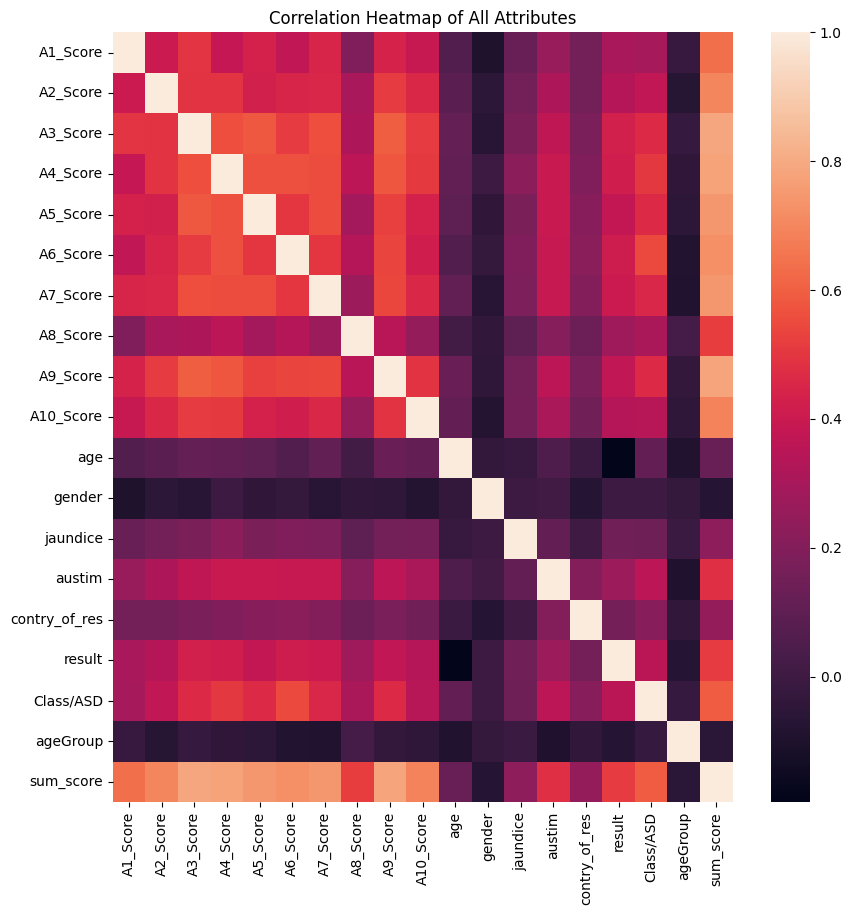

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder

def encode_labels(data):
    for col in data.columns:
      # Here we will check if datatype
      # is object then we will encode it
      if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
    return data

df = encode_labels(df)

# Making a heatmap to visualize the correlation matrix
plt.figure(figsize=(10,10))
sb.heatmap(df.corr())
plt.title('Correlation Heatmap of All Attributes')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 798 entries, 0 to 799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   A1_Score       798 non-null    int64  
 1   A2_Score       798 non-null    int64  
 2   A3_Score       798 non-null    int64  
 3   A4_Score       798 non-null    int64  
 4   A5_Score       798 non-null    int64  
 5   A6_Score       798 non-null    int64  
 6   A7_Score       798 non-null    int64  
 7   A8_Score       798 non-null    int64  
 8   A9_Score       798 non-null    int64  
 9   A10_Score      798 non-null    int64  
 10  age            798 non-null    float64
 11  gender         798 non-null    float64
 12  jaundice       798 non-null    int64  
 13  austim         798 non-null    int64  
 14  contry_of_res  798 non-null    int64  
 15  result         798 non-null    float64
 16  Class/ASD      798 non-null    int64  
 17  ageGroup       798 non-null    int64  
 18  sum_score      

In [ ]:
# Initialize MinMaxScaler
scaler_country = MinMaxScaler()
df['contry_of_res'] = scaler_country.fit_transform(df[['contry_of_res']])


Model Training

In [ ]:
removal = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','contry_of_res','result',]
features = df.drop( removal + ['austim'], axis=1)
target = df['austim']


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size = 0.2, random_state=10)

ros = RandomOverSampler(sampling_strategy='minority',random_state=0)
X, Y = ros.fit_resample(X_train,Y_train)
X.shape, Y.shape

((1064, 6), (1064,))

In [ ]:
#models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]
models = [LogisticRegression(), SVC(kernel='rbf')]

for model in models:
  model.fit(X, Y)

  print(f'{model} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(Y, model.predict(X)))
  print('Validation Accuracy : ', metrics.roc_auc_score(Y_val, model.predict(X_val)))
  print()

LogisticRegression() : 
Training Accuracy :  0.831766917293233
Validation Accuracy :  0.7814814814814814

SVC() : 
Training Accuracy :  0.8139097744360902
Validation Accuracy :  0.7651851851851852



In [ ]:
X_res, y_res = ros.fit_resample(X, Y)

# Train SVC (best model from evaluation)
model_best =  SVC(kernel='rbf')
model_best.fit(X_res, y_res)

print("Logistic Regression model trained successfully!")

print('Training Accuracy : ', metrics.roc_auc_score(y_res, model.predict(X_res)))
print('Validation Accuracy : ', metrics.roc_auc_score(Y_val, model.predict(X_val)))


Logistic Regression model trained successfully!
Training Accuracy :  0.8139097744360902
Validation Accuracy :  0.7651851851851852


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Artificial Neural Network (ANN) Model

In [ ]:
X_train_nn = X.values
Y_train_nn = Y.values
X_val_nn = X_val.values
Y_val_nn = Y_val.values

# Define the ANN model
model_ann = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_ann.fit(X_train_nn, Y_train_nn, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("ANN model trained successfully!")

# Evaluate the ANN model
loss, accuracy = model_ann.evaluate(X_val_nn, Y_val_nn, verbose=0)
print(f'Validation Accuracy (ANN): {accuracy:.4f}')

# Predict probabilities
Y_pred_ann = model_ann.predict(X_val_nn)
Y_pred_ann_binary = (Y_pred_ann > 0.5).astype(int)

# Calculate ROC AUC score for ANN
roc_auc_ann = metrics.roc_auc_score(Y_val_nn, Y_pred_ann_binary)
print(f'Validation ROC AUC (ANN): {roc_auc_ann:.4f}')


ANN model trained successfully!
Validation Accuracy (ANN): 0.7750
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Validation ROC AUC (ANN): 0.7689


In [ ]:

# Logistic Regression
model_lr = LogisticRegression()
model_lr.fit(X, Y)
'''
# XGBoost Classifier
model_xgb = XGBClassifier()
model_xgb.fit(X, Y)
'''
# SVC
model_svc = SVC(kernel='rbf', probability=True) # probability=True needed for ROC AUC with predict_proba
model_svc.fit(X, Y)



SVC(probability=True)

### Long Short-Term Memory (LSTM) Model

In [ ]:
X_train_lstm = X.values.reshape(X.shape[0], 1, X.shape[1])
Y_train_lstm = Y.values
X_val_lstm = X_val.values.reshape(X_val.shape[0], 1, X_val.shape[1])
Y_val_lstm = Y_val.values

# Define the LSTM model
model_lstm = keras.Sequential([
    layers.LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = model_lstm.fit(X_train_lstm, Y_train_lstm, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

print("LSTM model trained successfully!")

# Evaluate the LSTM model
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_val_lstm, Y_val_lstm, verbose=0)
print(f'Validation Accuracy (LSTM): {accuracy_lstm:.4f}')

Y_pred_lstm = model_lstm.predict(X_val_lstm)
Y_pred_lstm_binary = (Y_pred_lstm > 0.5).astype(int)

roc_auc_lstm = metrics.roc_auc_score(Y_val_lstm, Y_pred_lstm_binary)
print(f'Validation ROC AUC (LSTM): {roc_auc_lstm:.4f}')

LSTM model trained successfully!
Validation Accuracy (LSTM): 0.7812
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Validation ROC AUC (LSTM): 0.7563


In [ ]:
models_to_compare = {
    'Logistic Regression': model_lr,
    'LSTM': model_lstm,
 #   'XGBoost': model_xgb,
    'SVC': model_svc,
    'ANN': model_ann
}

# Evaluate all models
print("\n--- Updated Model Comparison ---")
for name, model in models_to_compare.items():
    if name == 'ANN':
        Y_pred_proba = model.predict(X_val_nn).flatten()
        Y_pred_binary = (Y_pred_proba > 0.5).astype(int)
        roc_auc = metrics.roc_auc_score(Y_val_nn, Y_pred_binary)
        accuracy = model.evaluate(X_val_nn, Y_val_nn, verbose=0)[1]
    elif name == 'LSTM':
        Y_pred_proba = model.predict(X_val_lstm).flatten()
        Y_pred_binary = (Y_pred_proba > 0.5).astype(int)
        roc_auc = metrics.roc_auc_score(Y_val_lstm, Y_pred_binary)
        accuracy = model.evaluate(X_val_lstm, Y_val_lstm, verbose=0)[1]
    else:
        Y_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_val)
        Y_pred_binary = model.predict(X_val)
        roc_auc = metrics.roc_auc_score(Y_val, Y_pred_binary)
        accuracy = metrics.accuracy_score(Y_val, Y_pred_binary)
    print(f'''{name}:
  Validation Accuracy: {accuracy:.4f}
  Validation ROC AUC: {roc_auc:.4f}''')



--- Updated Model Comparison ---
Logistic Regression:
  Validation Accuracy: 0.7688
  Validation ROC AUC: 0.7815
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
LSTM:
  Validation Accuracy: 0.7812
  Validation ROC AUC: 0.7563
SVC:
  Validation Accuracy: 0.7688
  Validation ROC AUC: 0.7652
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
ANN:
  Validation Accuracy: 0.7750
  Validation ROC AUC: 0.7689


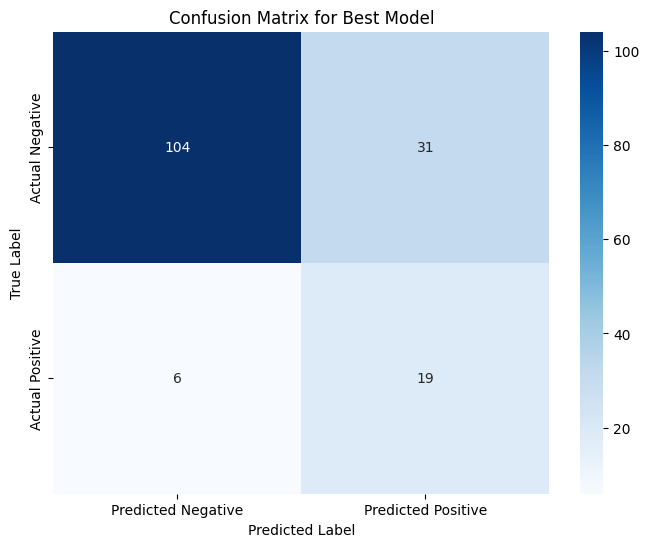

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make predictions on the test set using the best SVC model
y_pred_best = model_best.predict(X_val)

# Calculate the confusion matrix
cm = confusion_matrix(Y_val, y_pred_best)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Model')
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

question_texts = [
    "1. I prefer routines.",
    "2. I notice small sounds.",
    "3. People say I sound rude.",
    "4. I understand how others feel.",
    "5. I have strong interests.",
    "6. I get deeply absorbed.",
    "7. I understand others' thoughts.",
    "8. I enjoy social situations.",
    "9. I notice patterns easily.",
    "10. I find it hard to understand intentions."
]

yes_no_questions = []
for i, text in enumerate(question_texts):
    yes_no_questions.append(widgets.Checkbox(value=False, description=text))

age_widget = widgets.IntText(value=0, description='Age:')
gender_widget = widgets.Dropdown(options=['Male', 'Female'], description='Gender:')
jaundice_widget = widgets.Checkbox(value=False, description='Jaundice:')

model_selector = widgets.Dropdown(
    options={'Logistic Regression': model_lr, 'SVC': model_svc, 'ANN': model_ann, 'LSTM': model_lstm},
    description='Select Model:',
    disabled=False,
)

submit_button = widgets.Button(description="Submit")
output = widgets.Output()

input_vars = {}

def on_submit(b):
    with output:
        output.clear_output()
        answers = []
        for i, q in enumerate(yes_no_questions):
            if i in [3, 6, 7, 8]:
                answers.append(0 if q.value else 1)
            else:
                answers.append(1 if q.value else 0)

        age = age_widget.value
        gender = 1 if gender_widget.value == 'Male' else 0
        jaundice = 1 if jaundice_widget.value else 0

        sum_score = sum(answers)

        asd_derived = 1 if sum_score > 6 else 0

        if age < 4:
            age_group_label = 'Toddler'
        elif age < 12:
            age_group_label = 'Kid'
        elif age < 18:
            age_group_label = 'Teenager'
        elif age < 40:
            age_group_label = 'Young'
        else:
            age_group_label = 'Senior'


        age_group_mapping = {'Senior': 0, 'Kid': 1, 'Teenager': 2, 'Toddler': 3, 'Young': 4}
        age_group_encoded = age_group_mapping.get(age_group_label, -1)

        min_age = 2.718550
        max_age = 89.461718
        scaled_age = (age - min_age) / (max_age - min_age)
        scaled_age = max(0, min(1, scaled_age))


        input_array = [
            scaled_age,
            float(gender),
            float(jaundice),
            float(asd_derived),
            float(age_group_encoded),
            sum_score / 10.0
        ]

        selected_model = model_selector.value

        asdpred = np.array(input_array).reshape(1, -1)

        prediction_text = ""
        if isinstance(selected_model, keras.Sequential):
            if 'ANN' in model_selector.label:
                ann_prediction_proba = selected_model.predict(asdpred)[0][0]
                ann_prediction_binary = (ann_prediction_proba > 0.5).astype(int)
                prediction_text = f"ANN Prediction (Probability): {ann_prediction_proba:.4f} (Binary: {ann_prediction_binary})\n"
            elif 'LSTM' in model_selector.label:
                asdpred_lstm = asdpred.reshape(1, 1, asdpred.shape[1])
                lstm_prediction_proba = selected_model.predict(asdpred_lstm)[0][0]
                lstm_prediction_binary = (lstm_prediction_proba > 0.5).astype(int)
                prediction_text = f"LSTM Prediction (Probability): {lstm_prediction_proba:.4f} (Binary: {lstm_prediction_binary})\n"
        else:
            prediction = selected_model.predict(asdpred)[0]
            if hasattr(selected_model, 'predict_proba'):
                proba = selected_model.predict_proba(asdpred)[0, 1]
                prediction_text = f"{model_selector.label} Prediction (Probability): {proba:.4f} (Binary: {prediction})\n"
            elif hasattr(selected_model, 'decision_function'):
                decision_val = selected_model.decision_function(asdpred)[0]
                prediction_text = f"{model_selector.label} Prediction (Decision Value): {decision_val:.4f} (Binary: {prediction})\n"
            else:
                 prediction_text = f"{model_selector.label} Prediction: {prediction}\n"

        print(prediction_text)

submit_button.on_click(on_submit)

# Display widgets
display(*yes_no_questions, age_widget, gender_widget, jaundice_widget, model_selector, submit_button, output)


Checkbox(value=False, description='1. I prefer routines.')

Checkbox(value=False, description='2. I notice small sounds.')

Checkbox(value=False, description='3. People say I sound rude.')

Checkbox(value=False, description='4. I understand how others feel.')

Checkbox(value=False, description='5. I have strong interests.')

...

Dropdown(description='Gender:', options=('Male', 'Female'), value='Male')

Checkbox(value=False, description='Jaundice:')

Dropdown(description='Select Model:', options={'Logistic Regression': LogisticRegression(), 'SVC': SVC(probabi…

Button(description='Submit', style=ButtonStyle())

Output()